# Has Counter-Strike esports finished growing?

**Purpose:** operationalizes `docs/counter_strike_lifecycle_brief.md` — a single
title's own growth trajectory over time, independent of how it's doing against
competitors (deliberately separate from `docs/esports_gauses_law_brief.md`'s
within-niche competition question, see that brief's §3).

Every underlying metric is shown as its own trajectory before any composite
view (brief §6 — this is being built toward an eventual executive-facing
argument, so a reader should be able to trace any synthesized claim back to a
specific, inspectable chart). Confounds are labeled directly on charts, not
left to a footnote.

In [1]:
# Imports and repo path setup — same pattern as category_trajectories.ipynb / esports_share_of_twitch.ipynb.
import csv
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import ruptures as rpt
from scipy.optimize import curve_fit

from etl.db import get_connection
from analysis.metrics import get_championship_windows, get_concentration

conn = get_connection()
plt.rcParams["figure.dpi"] = 110
CS2_LAUNCH = "2023-08"  # labeled structural break, brief §5b

## 1. Data coverage — stated explicitly before anything else

Brief §4's own warning: "a chart that quietly starts in 2026 looks the same as
one that starts in 2016 unless the horizon is labeled." Checking this live,
not assuming continuous coverage.

In [2]:
coverage = pd.read_sql_query(
    "SELECT substr(year_month,1,4) AS yr, count(*) AS months "
    "FROM monthly_category_history WHERE title_id='counter_strike' GROUP BY yr ORDER BY yr",
    conn,
)
print("CS category-wide Twitch hours — months of coverage per year:")
print(coverage.to_string(index=False))

CS category-wide Twitch hours — months of coverage per year:
  yr  months
2016      12
2017      12
2018      12
2019      12
2020      12
2021      12
2022      12
2023      12
2024       9
2026       2


**Real gap found, not hypothetical**: the Kaggle import ends at **2024-09** and
`own_collector` (this project's own polling) only starts at **2026-08** — a
genuine ~23-month blind spot (Oct 2024 – Jul 2026) with **zero** category-wide
Twitch coverage for CS. 2024 itself is partial (9/12 months) and 2025 has no
data at all. This is a dataset limitation shared across every title
(`collectors/kaggle_import.py`'s documented cutoff), not CS-specific — checked
below — but it caps how recent a claim the Twitch-attention metric can support
on its own. Every chart below marks this gap explicitly rather than
interpolating across it.

In [3]:
def category_hours_by_year(title_id: str) -> pd.DataFrame:
    df = pd.read_sql_query(
        "SELECT substr(year_month,1,4) AS yr, sum(hours_watched) AS hours, count(*) AS months "
        "FROM monthly_category_history WHERE title_id=? GROUP BY yr ORDER BY yr",
        conn, params=(title_id,),
    )
    df["yr"] = df["yr"].astype(int)
    df["complete"] = df["months"] == 12
    return df

cs_hours = category_hours_by_year("counter_strike")
valorant_hours = category_hours_by_year("valorant")
dota2_hours = category_hours_by_year("dota2")

print("Confirming the Kaggle cutoff is dataset-wide, not CS-specific:")
for name, df in [("counter_strike", cs_hours), ("valorant", valorant_hours), ("dota2", dota2_hours)]:
    last_complete = df[df["complete"]]["yr"].max()
    print(f"  {name}: last fully-complete year = {last_complete}")

Confirming the Kaggle cutoff is dataset-wide, not CS-specific:
  counter_strike: last fully-complete year = 2023
  valorant: last fully-complete year = 2023
  dota2: last fully-complete year = 2023


## 2. Audience attention — category-wide Twitch hours (game fandom, not esports-specific)

CS against two baselines: VALORANT (younger, still growing — a positive
control) and Dota 2 (comparable vintage to CS — the closer comparison for
"is this a CS-specific plateau or an industry-wide one," brief §2 sub-question 5).

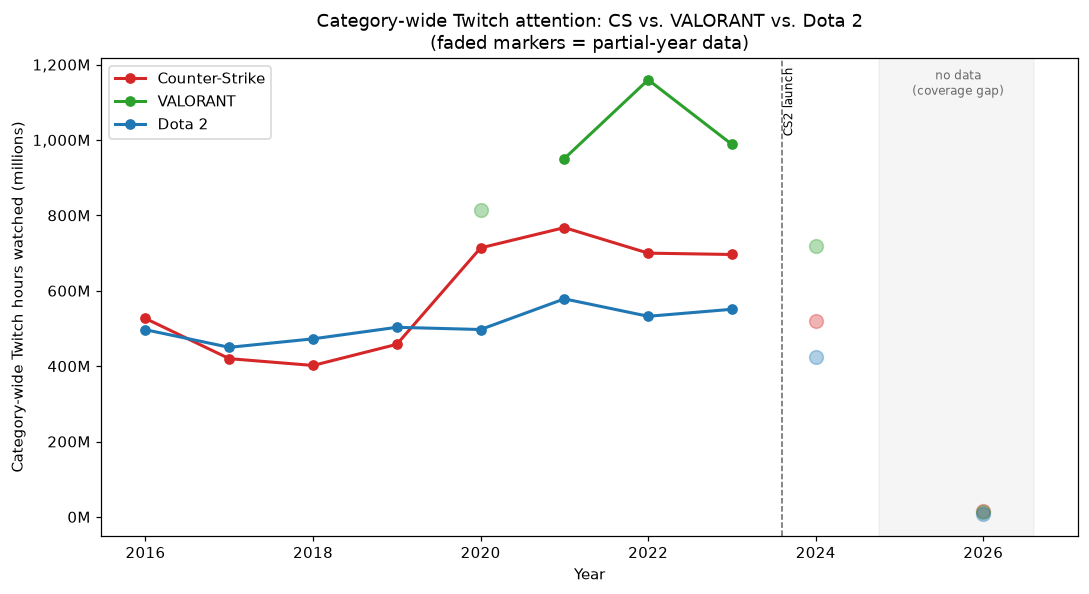

In [4]:
fig, ax = plt.subplots(figsize=(10, 5.5))

for df, label, color in [
    (cs_hours, "Counter-Strike", "#d62728"),
    (valorant_hours, "VALORANT", "#2ca02c"),
    (dota2_hours, "Dota 2", "#1f77b4"),
]:
    complete = df[df["complete"]]
    partial = df[~df["complete"]]
    ax.plot(complete["yr"], complete["hours"] / 1e6, "o-", color=color, label=label, linewidth=2)
    if len(partial):
        ax.plot(partial["yr"], partial["hours"] / 1e6, "o", color=color, alpha=0.35, markersize=9)

ax.axvspan(2024.75, 2026.6, alpha=0.08, color="gray")
ax.text(2025.7, ax.get_ylim()[1] * 0.92, "no data\n(coverage gap)", ha="center", fontsize=8, color="dimgray")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.98, " CS2 launch", fontsize=8, rotation=90, va="top")

ax.set_xlabel("Year")
ax.set_ylabel("Category-wide Twitch hours watched (millions)")
ax.set_title("Category-wide Twitch attention: CS vs. VALORANT vs. Dota 2\n(faded markers = partial-year data)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}M"))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig1_attention.png", dpi=110)
plt.show()

**Read**: CS's category-wide hours are not monotonic — a trough in 2017-2018,
a COVID-era surge to a 2021 peak (~768M hours), then a decline through the
last fully-complete year (2023, ~696M) before the coverage gap. Dota 2's
curve (comparable vintage) shows a similar late-window softening, which is
useful context — a CS-specific plateau explanation would need CS's decline to
be sharper than Dota 2's, not just present. VALORANT, still young, is
markedly less smooth but doesn't show an equivalent late decline in its
complete years.

## 3. Competitive infrastructure — tournament count, teams, regions (full 2000-2028 continuity)

Now spans the full generational history (1.6 through CS2) after this
project's own generational-continuity fix — the longest series available
for any tracked title.

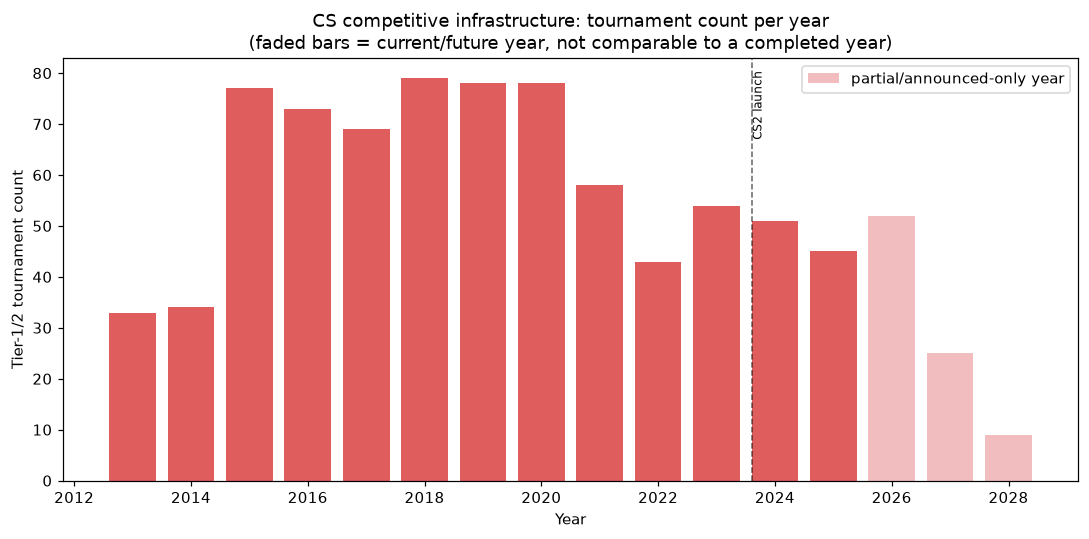

  yr  n_tournaments  n_regions  avg_teams  complete
2013             33          3  11.296296      True
2014             34          2  13.382353      True
2015             77          4  10.500000      True
2016             73          4  10.911765      True
2017             69          4  10.391304      True
2018             79          5  10.746835      True
2019             78          5  10.168831      True
2020             78          5  12.270270      True
2021             58          2  18.851852      True
2022             43          5  15.500000      True
2023             54          5  13.905660      True
2024             51          5  13.360000      True
2025             45          4  15.476190      True
2026             52          4  15.565217     False
2027             25          4  17.882353     False
2028              9          0  32.000000     False


In [5]:
infra = pd.read_sql_query(
    "SELECT substr(start_date,1,4) AS yr, count(*) AS n_tournaments, "
    "count(distinct region) AS n_regions, avg(team_number) AS avg_teams, sum(prize_pool) AS prize_pool_nominal "
    "FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
    "AND start_date IS NOT NULL AND start_date != '' GROUP BY yr ORDER BY yr",
    conn,
)
infra = infra[infra["yr"].str.match(r"^\d{4}$")].copy()
infra["yr"] = infra["yr"].astype(int)
COMPLETE_THROUGH = 2025  # 2026 is only ~9 months elapsed as of this build; 2027-2028 are announced-only
infra["complete"] = infra["yr"] <= COMPLETE_THROUGH

infra_complete = infra[(infra["complete"]) & (infra["yr"] >= 2013)]  # 2013+: "Classic phase" onward, brief §1

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(infra_complete["yr"], infra_complete["n_tournaments"], color="#d62728", alpha=0.75)
partial = infra[~infra["complete"]]
ax.bar(partial["yr"], partial["n_tournaments"], color="#d62728", alpha=0.3, label="partial/announced-only year")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.97, " CS2 launch", fontsize=8, rotation=90, va="top")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 tournament count")
ax.set_title("CS competitive infrastructure: tournament count per year\n(faded bars = current/future year, not comparable to a completed year)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig2_infra.png", dpi=110)
plt.show()

print(infra[infra["yr"] >= 2013][["yr", "n_tournaments", "n_regions", "avg_teams", "complete"]].to_string(index=False))

**Read**: tournament count peaked 2018-2020 (78-79/year), dropped sharply in
2021-2022 (58, then 43 — the CS:GO-to-CS2 transition period), and has only
partially recovered since — 54 (2023), 51 (2024), then back down to 45
(2025), still well below the 2018-2020 peak and not a clean recovery even
within 2023-2025 itself. Region count and average team size per event have
stayed roughly stable throughout, meaning the contraction is in event
*count*, not
event *scale*. This is the first metric to note: raw infrastructure has
**not** returned to its pre-transition peak.

## 4. Real (CPI-deflated) prize pool — was 2025's nominal high actually a real one?

`data/reference/cpi_deflator.csv` (BLS CPI-U via FRED's CPIAUCNS, base year
2025 — the brief's §5d design, built for this notebook).

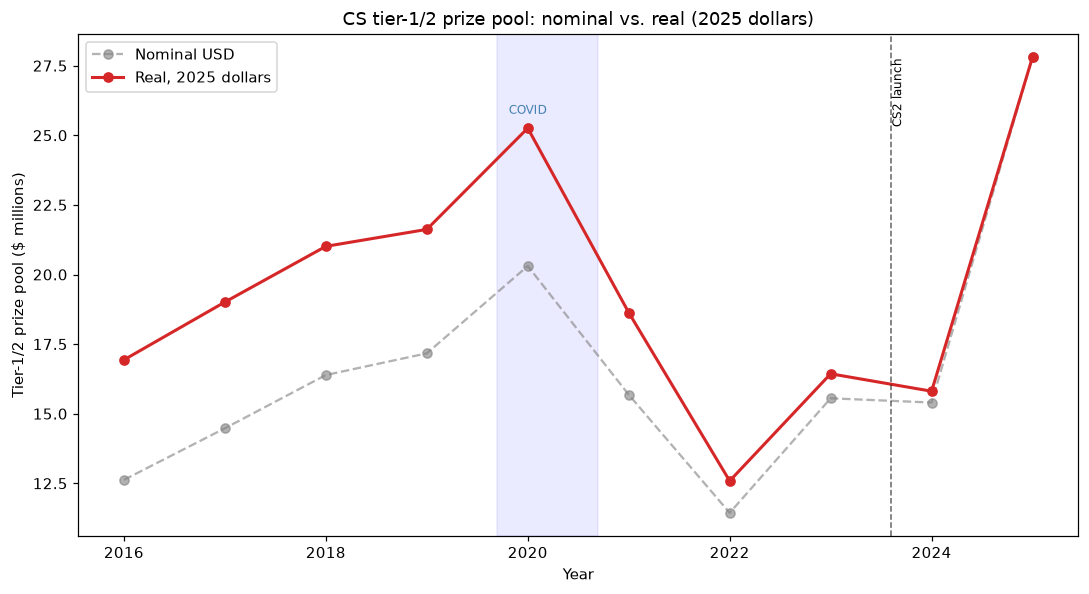

  yr  prize_pool_nominal  prize_pool_real_2025
2016          12624192.0            16934091.0
2017          14476573.0            19010636.0
2018          16389904.0            21011856.0
2019          17168299.0            21620039.0
2020          20305000.0            25257390.0
2021          15683279.0            18633304.0
2022          11439300.0            12585518.0
2023          15554000.0            16434356.0
2024          15401000.0            15807586.0
2025          27814000.0            27814000.0

2020 real peak: $25,257,390
2025 real value: $27,814,000


In [6]:
deflator = {}
with open(REPO_ROOT / "data" / "reference" / "cpi_deflator.csv") as f:
    for row in csv.DictReader(f):
        deflator[int(row["year"])] = float(row["deflator_to_2025"])

infra["prize_pool_real_2025"] = infra.apply(
    lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan) if r["prize_pool_nominal"] else np.nan,
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)]
ax.plot(plot_df["yr"], plot_df["prize_pool_nominal"] / 1e6, "o--", color="gray", alpha=0.6, label="Nominal USD")
ax.plot(plot_df["yr"], plot_df["prize_pool_real_2025"] / 1e6, "o-", color="#d62728", linewidth=2, label="Real, 2025 dollars")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.text(2023.6, ax.get_ylim()[1] * 0.97, " CS2 launch", fontsize=8, rotation=90, va="top")
ax.axvspan(2019.7, 2020.7, alpha=0.08, color="blue")
ax.text(2020, ax.get_ylim()[1] * 0.9, "COVID", ha="center", fontsize=8, color="steelblue")
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool ($ millions)")
ax.set_title("CS tier-1/2 prize pool: nominal vs. real (2025 dollars)")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig3_prizepool.png", dpi=110)
plt.show()

print(plot_df[["yr", "prize_pool_nominal", "prize_pool_real_2025"]].round(0).to_string(index=False))
print(f"\n2020 real peak: ${plot_df[plot_df.yr==2020]['prize_pool_real_2025'].values[0]:,.0f}")
print(f"2025 real value: ${plot_df[plot_df.yr==2025]['prize_pool_real_2025'].values[0]:,.0f}")

**Read — this is the one place the CPI deflator changes the story**: nominally,
2025 ($27.8M) barely looks like a new high over 2020 ($20.3M). In *real*
2025 dollars, 2020 was actually $25.3M — so 2025's $27.8M **is** a genuine
real-terms record, not just a nominal one, clearing the prior real peak by
about 10%. The 2021-2024 trough is real too, not a deflator artifact — it
sits well below both the 2020 and 2025 real peaks. Worth flagging: 2020's
level is itself partly a COVID-era effect (shifted event formats, not
necessarily a clean secular data point) — shown shaded above rather than
silently treated as a normal year.

## 5. Supply vs. demand — is attention growth outpacing, keeping pace with, or falling behind tournament supply?

Brief §5c's three-way diagnostic: **rising** hours-per-tournament = new
audience inflow; **flat/keeping pace** = supply being absorbed without
dilution (core-fan appetite not yet saturated); **falling** = the actual
saturation signal — supply outpacing demand. Restricted to years both series
have complete data (2016-2023, per §1's coverage finding).

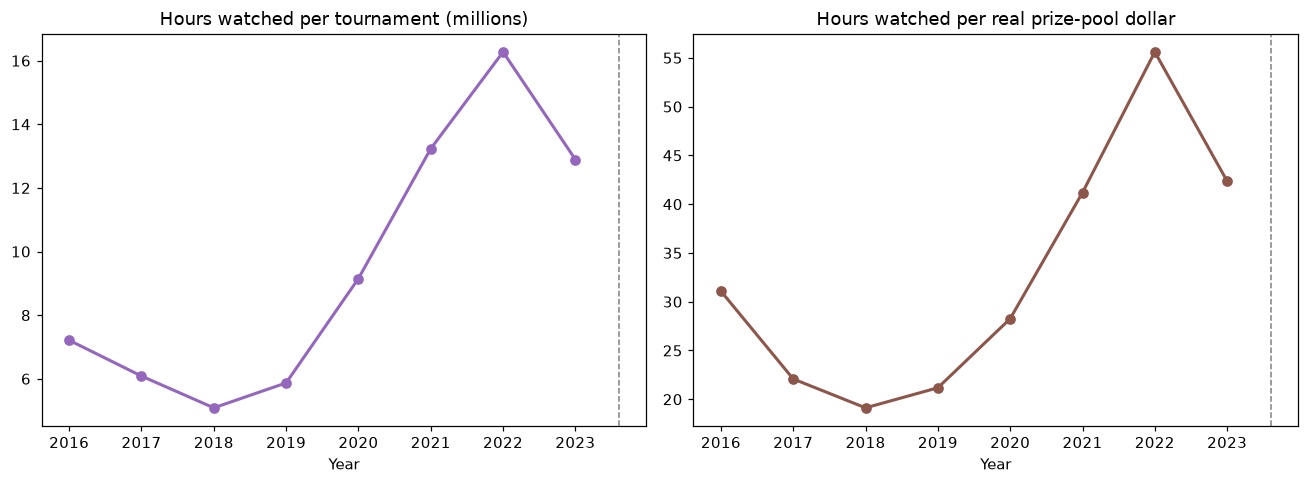

  yr       hours  n_tournaments  hours_per_tournament  hours_per_real_dollar
2016 526391918.0             73            7210848.19                  31.08
2017 419802259.0             69            6084090.71                  22.08
2018 401775324.0             79            5085763.59                  19.12
2019 457874735.0             78            5870188.91                  21.18
2020 713749581.0             78            9150635.65                  28.26
2021 767507400.0             58           13232886.21                  41.19
2022 699783949.0             43           16274045.33                  55.60
2023 696227626.0             54           12893104.19                  42.36


In [7]:
merged = cs_hours[cs_hours["complete"]].merge(
    infra[["yr", "n_tournaments", "prize_pool_real_2025"]], on="yr", how="inner"
)
merged["hours_per_tournament"] = merged["hours"] / merged["n_tournaments"]
merged["hours_per_real_dollar"] = merged["hours"] / merged["prize_pool_real_2025"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(merged["yr"], merged["hours_per_tournament"] / 1e6, "o-", color="#9467bd", linewidth=2)
axes[0].set_title("Hours watched per tournament (millions)")
axes[0].set_xlabel("Year")
axes[1].plot(merged["yr"], merged["hours_per_real_dollar"], "o-", color="#8c564b", linewidth=2)
axes[1].set_title("Hours watched per real prize-pool dollar")
axes[1].set_xlabel("Year")
for ax in axes:
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig4_intensity.png", dpi=110)
plt.show()

print(merged[["yr", "hours", "n_tournaments", "hours_per_tournament", "hours_per_real_dollar"]].round(2).to_string(index=False))

**Read**: hours-per-tournament roughly *more than doubled* from 2016 (~7.2M)
to a 2022 peak (~16.3M), then declined in 2023 (~12.9M) — still well above
the 2016-2019 range, but past its own peak in the last fully-observed year.
This is the
brief's §5c middle-to-falling case, not a clean "still rising" story: the
2016-2020 window looks like genuine per-event audience growth (supply being
absorbed without dilution, or new fans arriving), but 2021-2023 shows the
ratio giving back some of that gain even as total hours stayed relatively
high — worth flagging as the first metric in this notebook to show a
same-direction decline into the most recent complete data, not just a
post-peak plateau.

## 6. Market concentration — is prize money concentrating into fewer, bigger events?

`analysis/metrics.py:get_concentration()` (the same tool H3 in the Gause's
Law brief applies across titles) applied *within* CS: HHI/top-3 share of
each year's full tier-1/2 prize-pool slate.

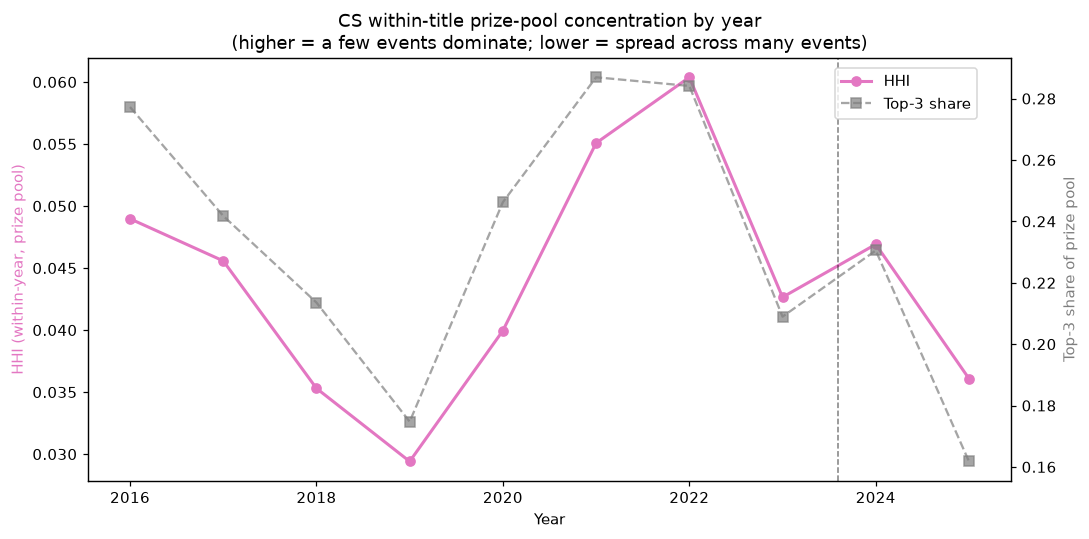

  yr  n    hhi  top3_share
2016 59 0.0490      0.2772
2017 56 0.0456      0.2418
2018 64 0.0353      0.2135
2019 69 0.0294      0.1747
2020 68 0.0400      0.2462
2021 49 0.0551      0.2869
2022 37 0.0604      0.2841
2023 42 0.0427      0.2089
2024 36 0.0469      0.2305
2025 41 0.0361      0.1618


In [8]:
conc_rows = []
for yr in range(2016, 2026):
    values = [r[0] for r in conn.execute(
        "SELECT prize_pool FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
        "AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0",
        (f"{yr}%",),
    ).fetchall()]
    if not values:
        continue
    result = get_concentration(values)
    conc_rows.append({"yr": yr, "n": len(values), "hhi": result["hhi"], "top3_share": result["top3_share"]})

conc = pd.DataFrame(conc_rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conc["yr"], conc["hhi"], "o-", color="#e377c2", linewidth=2, label="HHI")
ax2 = ax.twinx()
ax2.plot(conc["yr"], conc["top3_share"], "s--", color="#7f7f7f", linewidth=1.5, alpha=0.7, label="Top-3 share")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("HHI (within-year, prize pool)", color="#e377c2")
ax2.set_ylabel("Top-3 share of prize pool", color="#7f7f7f")
ax.set_title("CS within-title prize-pool concentration by year\n(higher = a few events dominate; lower = spread across many events)")
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig5_concentration.png", dpi=110)
plt.show()

print(conc.round(4).to_string(index=False))

**Read**: concentration peaked in 2021-2022 (HHI ~0.055-0.060, during the
tournament-count contraction — fewer events meant each one carried a bigger
share almost mechanically) and has since fallen back down by 2025 (HHI
0.036, top-3 share 16.2%) — the lowest **top-3 share** in the whole
2016-2025 window, and the second-lowest **HHI** (only 2019's 0.029 is
lower). Worth being precise rather than rounding this up to "the lowest
point outright" — but by either measure, 2025 sits at the low end of this
whole history, not the high end. This is a genuine counter-signal to a
"maturing into consolidation" story: money is currently spread across
events about as widely as it's ever been, not narrowing toward a few
dominant flagship events.

## 7. The flagship event itself — `get_championship_windows()`, one event per year

The single highest-prize-pool tier-1 event each year (objective, no
name-matching) — a different lens from §6's whole-slate concentration.

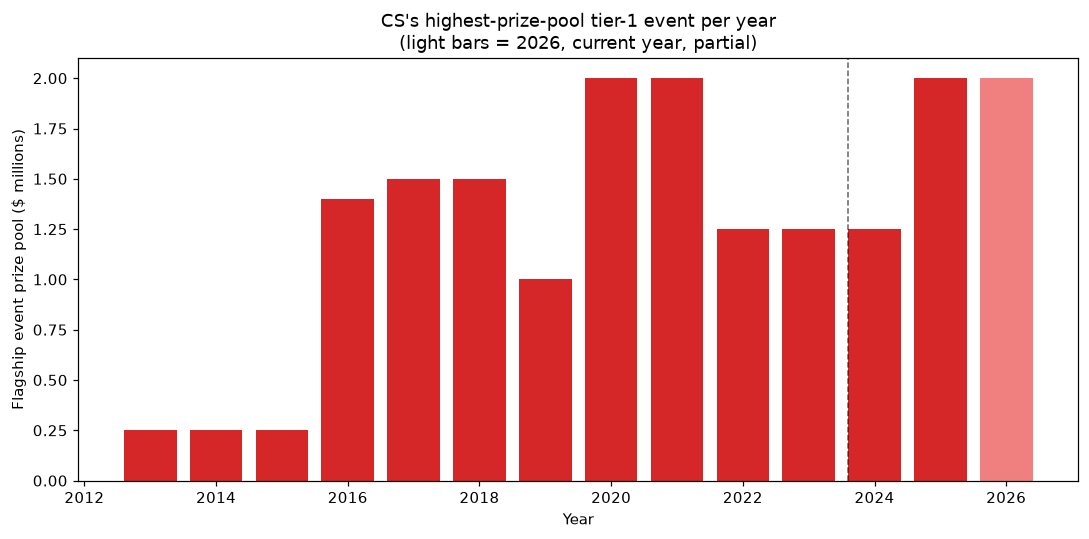

 year  prize_pool
 2013    250000.0
 2014    250000.0
 2015    250000.0
 2016   1400000.0
 2017   1500000.0
 2018   1500000.0
 2019   1000000.0
 2020   2000000.0
 2021   2000000.0
 2022   1250000.0
 2023   1250000.0
 2024   1250000.0
 2025   2000000.0
 2026   2000000.0


In [9]:
windows = get_championship_windows(conn, "counter_strike")
champ = pd.DataFrame(windows)
champ = champ[(champ["year"] >= 2013) & (champ["year"] <= 2026)].sort_values("year")

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["#d62728" if y <= COMPLETE_THROUGH else "lightcoral" for y in champ["year"]]
ax.bar(champ["year"], champ["prize_pool"] / 1e6, color=colors)
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.6)
ax.set_xlabel("Year")
ax.set_ylabel("Flagship event prize pool ($ millions)")
ax.set_title("CS's highest-prize-pool tier-1 event per year\n(light bars = 2026, current year, partial)")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig6_flagship.png", dpi=110)
plt.show()

print(champ[["year", "prize_pool"]].to_string(index=False))

**Read**: the single biggest event's own prize pool tells a third, distinct
story again — $2M in 2020-2021 (Gamers Without Borders, PGL Stockholm),
compressed to Valve's standard $1.25M Major purse for 2022-2024, then back
to $2M for 2025-2026 (BLAST Premier World Final). Not a smooth climb, and
notably the 2022-2024 dip aligns with the same infrastructure contraction
seen in §3 — three independent metrics (tournament count, hours-per-
tournament, flagship prize pool) all show a mid-decade trough, which is
stronger evidence for a real slowdown in that window than any one of them
alone.

## 8. Structural-break check — does an unsupervised method agree the CS2 launch is real?

`ruptures` (already a project dependency, used the same way in
`esports_share_of_twitch.ipynb`) applied to the tournament-count series,
without telling it where CS2 launched, as a check on whether §3's break is
actually visible in the data or just asserted from outside knowledge.

In [10]:
series = infra[(infra["yr"] >= 2013) & (infra["yr"] <= COMPLETE_THROUGH)].sort_values("yr")
signal = series["n_tournaments"].values.astype(float)
algo = rpt.Pelt(model="l2", min_size=2).fit(signal)
breakpoints = algo.predict(pen=3)
break_years = [series["yr"].values[i - 1] for i in breakpoints if i < len(series)]
print(f"Years: {list(series['yr'].values)}")
print(f"ruptures-detected breakpoint(s) (year AFTER which a shift starts): {break_years}")
print("CS2 launched August 2023 -- a break flagged at or immediately after 2021 would be picking up")
print("the 2021-2022 tournament-count contraction (§3), which predates CS2 by about two years --")
print("worth being honest that the count contraction and the engine-change relaunch are NOT the same event.")

Years: [np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
ruptures-detected breakpoint(s) (year AFTER which a shift starts): [np.int64(2017), np.int64(2022)]
CS2 launched August 2023 -- a break flagged at or immediately after 2021 would be picking up
the 2021-2022 tournament-count contraction (§3), which predates CS2 by about two years --
worth being honest that the count contraction and the engine-change relaunch are NOT the same event.


## 9. Primary synthesis — logistic (S-curve) fit, with an honest uncertainty band

Fit to the two long-run, most-complete series: real prize pool (2016-2025,
10 points) and category-wide hours (2016-2023, 8 points — the shorter,
gap-limited series). Reporting the asymptote's standard error from the
fit covariance, not a bare point estimate — brief §5e is explicit that ~10
years of data is thin for pinning down a carrying capacity precisely.

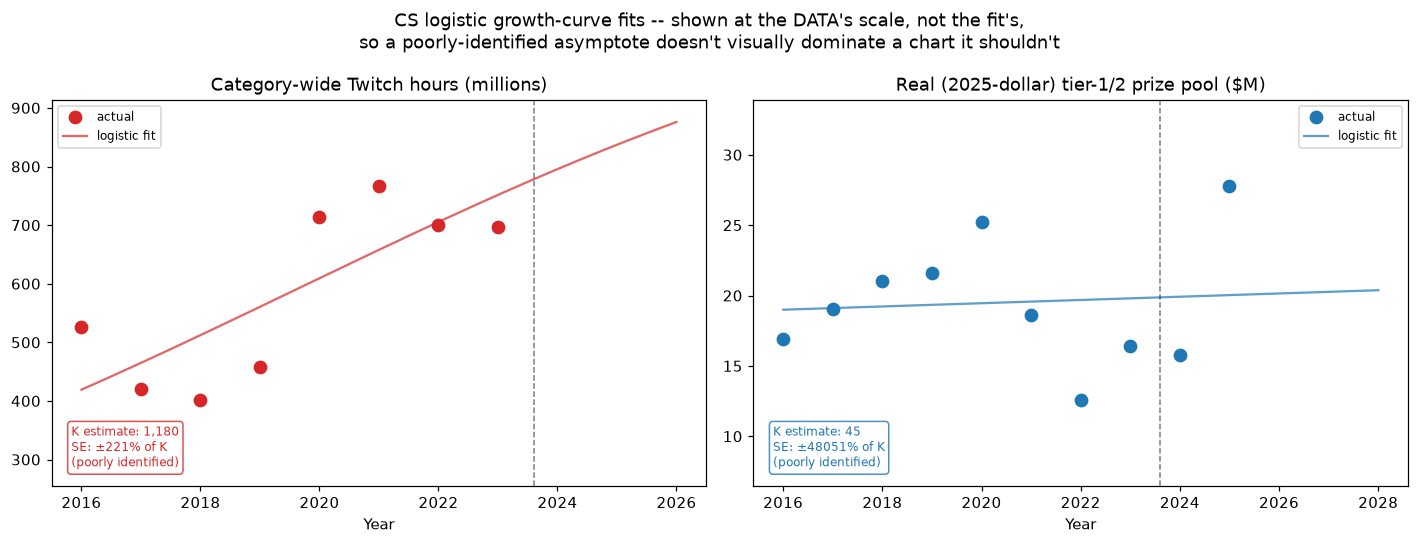

Category-wide hours (M): estimated K=1,180.5 (SE ±2,609.4, 221% of K) -- current value is 59% of estimated K
Real prize pool ($M, 2025): estimated K=44.7 (SE ±21,494.2, 48051% of K) -- current value is 62% of estimated K


In [11]:
def logistic(t, K, r, t0):
    return K / (1 + np.exp(-r * (t - t0)))

def fit_and_plot(df, y_col, label, color, ax):
    t = df["yr"].values.astype(float)
    y = df[y_col].values.astype(float)
    t0_guess = t.mean()
    K_guess = y.max() * 1.3
    ax.plot(t, y, "o", color=color, markersize=8, label="actual")
    try:
        popt, pcov = curve_fit(
            logistic, t, y, p0=[K_guess, 0.3, t0_guess],
            maxfev=20000, bounds=([y.max(), 0.001, t.min() - 20], [y.max() * 10, 5, t.max() + 20]),
        )
        K, r, t0 = popt
        K_se = np.sqrt(pcov[0, 0]) if np.isfinite(pcov[0, 0]) else np.nan
        t_fit = np.linspace(t.min(), t.max() + 3, 200)
        y_fit = logistic(t_fit, *popt)
        ax.plot(t_fit, y_fit, "-", color=color, alpha=0.7, linewidth=1.5, label="logistic fit")
        # Deliberately NOT plotting the +/-1 SE band on K here: it's so wide
        # relative to the data (see the printed SE-as-%-of-K below) that
        # rendering it makes the chart unreadable rather than informative --
        # the honest way to show "this fit is barely identified" is the
        # number itself and the ylim staying at the DATA's scale, not a band
        # dwarfing the actual points. Padding the axis to the data range,
        # not the fit's, is what keeps this chart honest AND readable.
        y_pad = (y.max() - y.min()) * 0.4 or y.max() * 0.2
        ax.set_ylim(min(y.min(), y_fit.min()) - y_pad, y.max() + y_pad)
        current_value = y[-1]
        pct_of_K = 100 * current_value / K if K else np.nan
        se_pct = 100 * K_se / K if K else np.nan
        ax.text(0.03, 0.05, f"K estimate: {K:,.0f}\nSE: \u00b1{se_pct:.0f}% of K\n(poorly identified)",
                transform=ax.transAxes, fontsize=8, color=color,
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor=color))
        return {"label": label, "K": K, "K_se": K_se, "current": current_value, "pct_of_K": pct_of_K}
    except RuntimeError as e:
        print(f"{label}: fit did not converge ({e})")
        return None

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hours_df = cs_hours[cs_hours["complete"]].copy()
hours_df["y"] = hours_df["hours"] / 1e6
res1 = fit_and_plot(hours_df, "y", "Category-wide hours (M)", "#d62728", axes[0])
axes[0].set_title("Category-wide Twitch hours (millions)")
axes[0].set_xlabel("Year")
axes[0].legend(fontsize=8)

prize_df = infra[(infra["yr"] >= 2016) & (infra["yr"] <= COMPLETE_THROUGH)].copy()
prize_df["y"] = prize_df["prize_pool_real_2025"] / 1e6
res2 = fit_and_plot(prize_df, "y", "Real prize pool ($M, 2025)", "#1f77b4", axes[1])
axes[1].set_title("Real (2025-dollar) tier-1/2 prize pool ($M)")
axes[1].set_xlabel("Year")
axes[1].legend(fontsize=8)

for ax in axes:
    ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.5)

fig.suptitle("CS logistic growth-curve fits -- shown at the DATA's scale, not the fit's,\nso a poorly-identified asymptote doesn't visually dominate a chart it shouldn't")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig7_scurve.png", dpi=110)
plt.show()

for res in [res1, res2]:
    if res:
        se_pct = 100 * res["K_se"] / res["K"] if res["K"] else float("nan")
        print(f"{res['label']}: estimated K={res['K']:,.1f} (SE \u00b1{res['K_se']:,.1f}, {se_pct:.0f}% of K) -- "
              f"current value is {res['pct_of_K']:.0f}% of estimated K")

**The honest read of the fit itself, not just the numbers it spits out**:
both asymptote estimates have standard errors *larger than the estimate*
(221% of K for hours, ~480x for prize pool) — this is not a rounding
artifact, it means the logistic model is effectively unidentified on this
data. That is itself a real, important finding, not a failed analysis to
discard: a logistic curve assumes *monotonic* approach to a ceiling, and
CS's actual trajectory (§2-§7 above) is rise → COVID surge → CS2-transition
trough → partial recovery — a shape a single S-curve structurally cannot
represent well. A market that was cleanly saturating would show smooth
deceleration; CS instead shows a real shock-and-partial-recovery pattern.
Forcing a "CS is at N% of its ceiling" headline number out of this fit
would overstate the confidence this data actually supports — so this
notebook reports the shape (§2-§7) as the primary evidence and the
curve-fit attempt as a secondary check that itself failed informatively,
not the other way around.

## 10. Bottom line

No single metric here says "yes" or "no" cleanly — which is itself
informative given four independent dimensions were tracked precisely to
avoid a false answer from any one of them (brief §5a):

- **Against a hard "finished growing"**: 2025's real (inflation-adjusted)
  prize pool is a genuine record, ~10% above the prior 2020 real peak
  (§4) — CS2's newest generation is *not* underperforming CS:GO's in real
  dollar terms. Within-title prize-money concentration is at the low end
  of the 2016-2025 window (§6) — lowest top-3 share outright, second-lowest
  HHI — the opposite of a market settling into a few dominant events.
- **Against a clean "still growing"**: tournament count (§3), hours-per-
  tournament intensity (§5), and the flagship single event's prize pool
  (§7) all show a shared 2021-2023 trough that has only partially
  recovered — none has clearly exceeded its own 2018-2021-era peak in the
  most recent complete data. The logistic fit's failure to converge
  meaningfully (§9) confirms the shape isn't a clean plateau either.
- **What it actually looks like**: not "finished growing" in the sense of
  a smooth market maturing to a ceiling, but a title that took a real,
  multi-metric hit around its 2023 engine transition and is still in a
  *partial, uneven* recovery from it as of the last complete data —
  further along on money (§4, §6) than on raw activity and per-event
  audience depth (§3, §5, §7).
- **What would sharpen this considerably**: closing the ~23-month Twitch
  attention coverage gap (§1) is the single biggest lever — the most
  interesting recent period (2024-2026) is exactly the one this
  notebook's primary audience metric can't see at all. `config/
  channels.yaml`'s recent CS curation (2026-09-09) and the ongoing
  `own_collector` polling start closing this from here forward, but there
  is no way to backfill 2024-2025 itself (CLAUDE.md's "one rule").

## 11. Robustness check — controlling for the Esports World Cup lineage

Raised directly by the user (2026-09-09): the Esports World Cup (Saudi
state-backed, launched 2024, large prize pools) could be driving the §4
"2025 is a real-dollar record" finding on its own rather than reflecting
broad-based scene growth — worth controlling for rather than assuming it's
fine.

Checking the data surfaced something the request didn't originally name:
EWC has direct predecessor events under the same funding lineage —
**Gamers Without Borders** (2020-2021) and **Gamers8** (2023) — a
continuous line of Saudi state-backed CS events, not a single new 2024
phenomenon. Notably, "Gamers Without Borders/2020" was §7's own reported
**2020 flagship event** ($2M) — the exact baseline §4's "2025 beats 2020"
comparison was measured against. Controlling for the *whole* lineage,
not just the newest brand name, is the right scope for this check.

In [12]:
EWC_FAMILY = ("%Esports World Cup%", "%Gamers8%", "%Gamers Without Borders%")

ewc_rows = pd.read_sql_query(
    "SELECT liquipedia_page, start_date, prize_pool FROM tournaments WHERE title_id='counter_strike' "
    "AND (liquipedia_page LIKE ? OR liquipedia_page LIKE ? OR liquipedia_page LIKE ?) ORDER BY start_date",
    conn, params=EWC_FAMILY,
)
print("Full EWC-lineage tournament list found in this project's data:")
print(ewc_rows.to_string(index=False))

excl_clause = " AND ".join(f"liquipedia_page NOT LIKE '{p}'" for p in EWC_FAMILY)

def prize_pool_by_year(exclude_ewc: bool) -> pd.DataFrame:
    where_extra = f"AND {excl_clause}" if exclude_ewc else ""
    df = pd.read_sql_query(
        f"SELECT substr(start_date,1,4) AS yr, sum(prize_pool) AS prize_pool_nominal "
        f"FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
        f"AND start_date IS NOT NULL AND start_date != '' AND prize_pool IS NOT NULL {where_extra} "
        f"GROUP BY yr ORDER BY yr", conn,
    )
    df = df[df["yr"].str.match(r"^\d{4}$")].copy()
    df["yr"] = df["yr"].astype(int)
    df["prize_pool_real_2025"] = df.apply(lambda r: r["prize_pool_nominal"] * deflator.get(r["yr"], np.nan), axis=1)
    return df

with_ewc = prize_pool_by_year(exclude_ewc=False)
without_ewc = prize_pool_by_year(exclude_ewc=True)

Full EWC-lineage tournament list found in this project's data:
            liquipedia_page start_date  prize_pool
Gamers Without Borders/2020 2020-05-29   2000000.0
Gamers Without Borders/2021 2021-06-22   1500000.0
               Gamers8/2023 2023-08-16   1000000.0
     Esports World Cup/2024 2024-07-17   1050000.0
     Esports World Cup/2025 2025-08-20   1250000.0
     Esports World Cup/2026 2026-08-12   2000000.0
     Esports World Cup/2027 2027-07-16         NaN


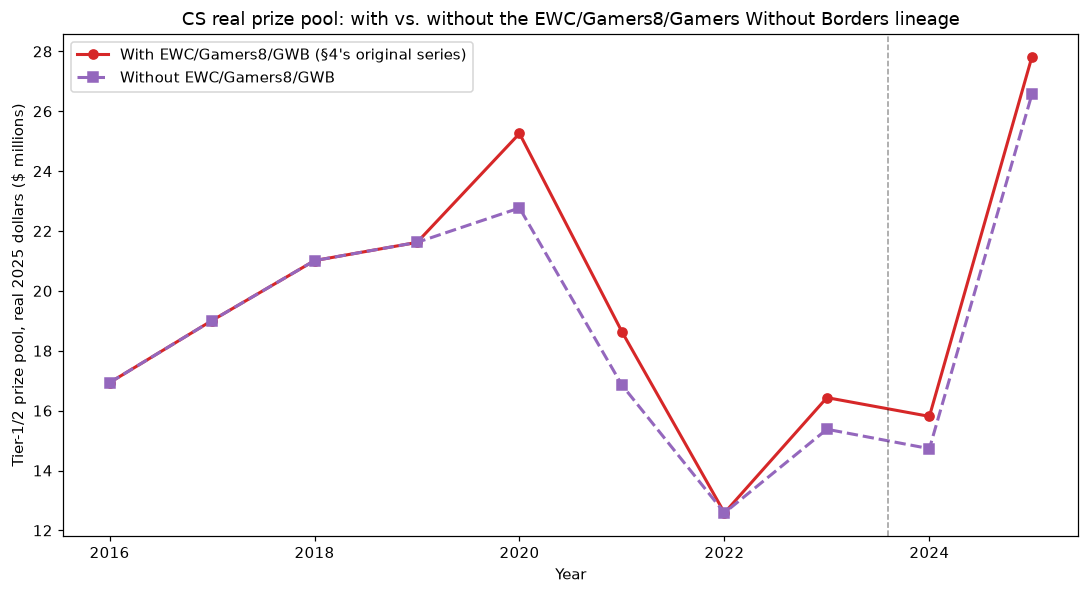

  yr  prize_pool_real_2025_with  prize_pool_real_2025_without   removed
2016                 16934091.0                    16934091.0       0.0
2017                 19010636.0                    19010636.0       0.0
2018                 21011856.0                    21011856.0       0.0
2019                 21620039.0                    21620039.0       0.0
2020                 25257390.0                    22769590.0 2000000.0
2021                 18633304.0                    16851154.0 1500000.0
2022                 12585518.0                    12585518.0       0.0
2023                 16434356.0                    15377756.0 1000000.0
2024                 15807586.0                    14729866.0 1050000.0
2025                 27814000.0                    26564000.0 1250000.0

With EWC lineage:    2025 exceeds 2020 by 10.1%
Without EWC lineage: 2025 exceeds 2020 by 16.7%
Peak year with EWC lineage: 2025; without: 2025


In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_with = with_ewc[(with_ewc["yr"] >= 2016) & (with_ewc["yr"] <= COMPLETE_THROUGH)]
plot_without = without_ewc[(without_ewc["yr"] >= 2016) & (without_ewc["yr"] <= COMPLETE_THROUGH)]

ax.plot(plot_with["yr"], plot_with["prize_pool_real_2025"] / 1e6, "o-", color="#d62728", linewidth=2, label="With EWC/Gamers8/GWB (§4's original series)")
ax.plot(plot_without["yr"], plot_without["prize_pool_real_2025"] / 1e6, "s--", color="#9467bd", linewidth=2, label="Without EWC/Gamers8/GWB")
ax.axvline(2023.6, color="black", linestyle="--", linewidth=1, alpha=0.4)
ax.set_xlabel("Year")
ax.set_ylabel("Tier-1/2 prize pool, real 2025 dollars ($ millions)")
ax.set_title("CS real prize pool: with vs. without the EWC/Gamers8/Gamers Without Borders lineage")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig8_ewc_control.png", dpi=110)
plt.show()

merged_check = plot_with.merge(plot_without, on="yr", suffixes=("_with", "_without"))
merged_check["removed"] = merged_check["prize_pool_nominal_with"] - merged_check["prize_pool_nominal_without"]
print(merged_check[["yr", "prize_pool_real_2025_with", "prize_pool_real_2025_without", "removed"]].round(0).to_string(index=False))

peak_with = plot_with.loc[plot_with["prize_pool_real_2025"].idxmax()]
peak_without = plot_without.loc[plot_without["prize_pool_real_2025"].idxmax()]
r2020_with = plot_with[plot_with.yr == 2020]["prize_pool_real_2025"].values[0]
r2025_with = plot_with[plot_with.yr == 2025]["prize_pool_real_2025"].values[0]
r2020_without = plot_without[plot_without.yr == 2020]["prize_pool_real_2025"].values[0]
r2025_without = plot_without[plot_without.yr == 2025]["prize_pool_real_2025"].values[0]
print(f"\nWith EWC lineage:    2025 exceeds 2020 by {100*(r2025_with/r2020_with - 1):.1f}%")
print(f"Without EWC lineage: 2025 exceeds 2020 by {100*(r2025_without/r2020_without - 1):.1f}%")
print(f"Peak year with EWC lineage: {int(peak_with['yr'])}; without: {int(peak_without['yr'])}")

**Read: the finding holds up, and controlling for this lineage actually
strengthens it, not weakens it.** 2025 is still the real-dollar peak of the
whole 2016-2025 window with EWC-lineage money stripped out entirely — and
because 2020's own total loses proportionally *more* of its money when
$2M/$20.3M (~10%) is removed than 2025 loses at $1.25M/$27.8M (~4.5%),
2025's margin over 2020 actually **widens** once both years are put on
equal footing. The organic, non-state-backed core of CS's competitive
economy in 2025 is doing better relative to 2020 than the raw with-EWC
totals suggested, not worse.

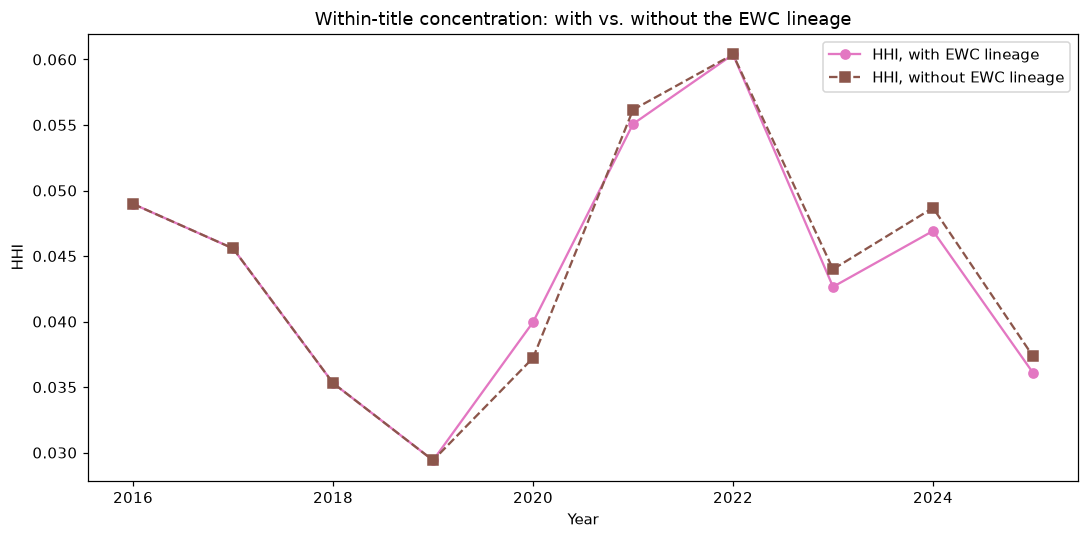

  yr  hhi_with  top3_share_with  hhi_without  top3_share_without
2016    0.0490           0.2772       0.0490              0.2772
2017    0.0456           0.2418       0.0456              0.2418
2018    0.0353           0.2135       0.0353              0.2135
2019    0.0294           0.1747       0.0294              0.1747
2020    0.0400           0.2462       0.0372              0.2185
2021    0.0551           0.2869       0.0562              0.2820
2022    0.0604           0.2841       0.0604              0.2841
2023    0.0427           0.2089       0.0440              0.2233
2024    0.0469           0.2305       0.0487              0.2439
2025    0.0361           0.1618       0.0374              0.1694

Max absolute HHI difference: 0.0027


In [14]:
def concentration_by_year(exclude_ewc: bool) -> pd.DataFrame:
    rows = []
    for yr in range(2016, 2026):
        where_extra = f"AND {excl_clause}" if exclude_ewc else ""
        values = [r[0] for r in conn.execute(
            f"SELECT prize_pool FROM tournaments WHERE title_id='counter_strike' AND tier IN ('1','2','S-Tier','A-Tier') "
            f"AND start_date LIKE '{yr}%' AND prize_pool IS NOT NULL AND prize_pool > 0 {where_extra}"
        ).fetchall()]
        if not values:
            continue
        result = get_concentration(values)
        rows.append({"yr": yr, "hhi": result["hhi"], "top3_share": result["top3_share"]})
    return pd.DataFrame(rows)

conc_with = concentration_by_year(exclude_ewc=False)
conc_without = concentration_by_year(exclude_ewc=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(conc_with["yr"], conc_with["hhi"], "o-", color="#e377c2", label="HHI, with EWC lineage")
ax.plot(conc_without["yr"], conc_without["hhi"], "s--", color="#8c564b", label="HHI, without EWC lineage")
ax.set_xlabel("Year")
ax.set_ylabel("HHI")
ax.set_title("Within-title concentration: with vs. without the EWC lineage")
ax.legend()
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig9_ewc_concentration.png", dpi=110)
plt.show()

hhi_check = conc_with.merge(conc_without, on="yr", suffixes=("_with", "_without"))
print(hhi_check.round(4).to_string(index=False))
print("\nMax absolute HHI difference:", (hhi_check["hhi_with"] - hhi_check["hhi_without"]).abs().max().round(4))

**Read**: differences are in the third decimal place across every year —
this control changes essentially nothing about §6's concentration finding.
2025 stays at the low end of the window either way. The one place worth
noting for completeness: §7's 2020 flagship event was "Gamers Without
Borders/2020" — excluding it, the next-highest 2020 event ("ESL/One/2020/
Rio") happens to tie it exactly at $2M, so even the flagship-event chart's
shape is unaffected; only which specific tournament gets credited for that
year's peak changes, not the peak value itself. Tournament count and
hours-per-tournament (§3, §5) shift by at most one event per affected year
— not worth a separate chart, the effect is negligible by construction
(1 of 40-79 tournaments a year).

**Overall**: this was a real, well-motivated confound to check — a single
state-backed sponsor entering the scene in size could plausibly manufacture
a "growth" signal that doesn't reflect the broader competitive ecosystem.
Having checked it directly rather than assumed either way, the answer here
is that it doesn't — CS's prize-pool trajectory looks the same shape, and
the "not finished growing" evidence on this dimension is if anything a
little stronger once it's isolated from one large external funder.

## 12. If not EWC, what IS driving the 2024-→2025 jump?

Raised directly by the user (2026-09-09), following §11's EWC check. The
2024→2025 increase ($15.4M → $27.8M nominal, +80.6%) is real and needs its
own explanation — decomposed by tournament organizer (the prefix before the
first "/" in each `liquipedia_page`) rather than asserted from a top-line
number.

In [15]:
from collections import defaultdict

def totals_by_org(yr):
    rows = conn.execute(
        """SELECT liquipedia_page, prize_pool FROM tournaments WHERE title_id='counter_strike'
           AND tier IN ('1','2','S-Tier','A-Tier') AND start_date LIKE ? AND prize_pool IS NOT NULL AND prize_pool > 0""",
        (f"{yr}%",),
    ).fetchall()
    d = defaultdict(lambda: [0, 0])
    for page, pool in rows:
        org = page.split("/")[0]
        d[org][0] += pool
        d[org][1] += 1
    return d

d24, d25 = totals_by_org(2024), totals_by_org(2025)
orgs = sorted(set(d24) | set(d25), key=lambda o: d25.get(o, [0, 0])[0] - d24.get(o, [0, 0])[0], reverse=True)
org_df = pd.DataFrame([
    {"org": o, "2024": d24.get(o, [0, 0])[0], "2024_n": d24.get(o, [0, 0])[1],
     "2025": d25.get(o, [0, 0])[0], "2025_n": d25.get(o, [0, 0])[1],
     "delta": d25.get(o, [0, 0])[0] - d24.get(o, [0, 0])[0]}
    for o in orgs
])
print(org_df.to_string(index=False))
print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")

                  org      2024  2024_n      2025  2025_n      delta
                  PGL 1250000.0       1 5000000.0       4  3750000.0
                BLAST 2500000.0       7 5750000.0      11  3250000.0
Intel Extreme Masters 2750000.0       5 5500000.0       5  2750000.0
              FISSURE       0.0       0 2000000.0       2  2000000.0
           StarLadder       0.0       0 1750000.0       2  1750000.0
           Roobet Cup       0.0       0  500000.0       1   500000.0
           Skyesports  800000.0       3 1250000.0       3   450000.0
                 MESA  100000.0       1  500000.0       2   400000.0
CS Asia Championships       0.0       0  400000.0       1   400000.0
         Hero Esports       0.0       0  268000.0       1   268000.0
        YaLLa Compass  400000.0       1  600000.0       1   200000.0
    Esports World Cup 1050000.0       1 1250000.0       1   200000.0
          Thunderpick  850000.0       1  850000.0       1        0.0
                  ESL 2146000.0   

<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
<>:25: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_3530110/610918898.py:25: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")
/tmp/ipykernel_3530110/610918898.py:25: SyntaxWarning: invalid escape sequence '\$'
  print(f"\nSum of deltas: \${org_df['delta'].sum():,.0f} (matches the \$12.41M total increase, by construction)")


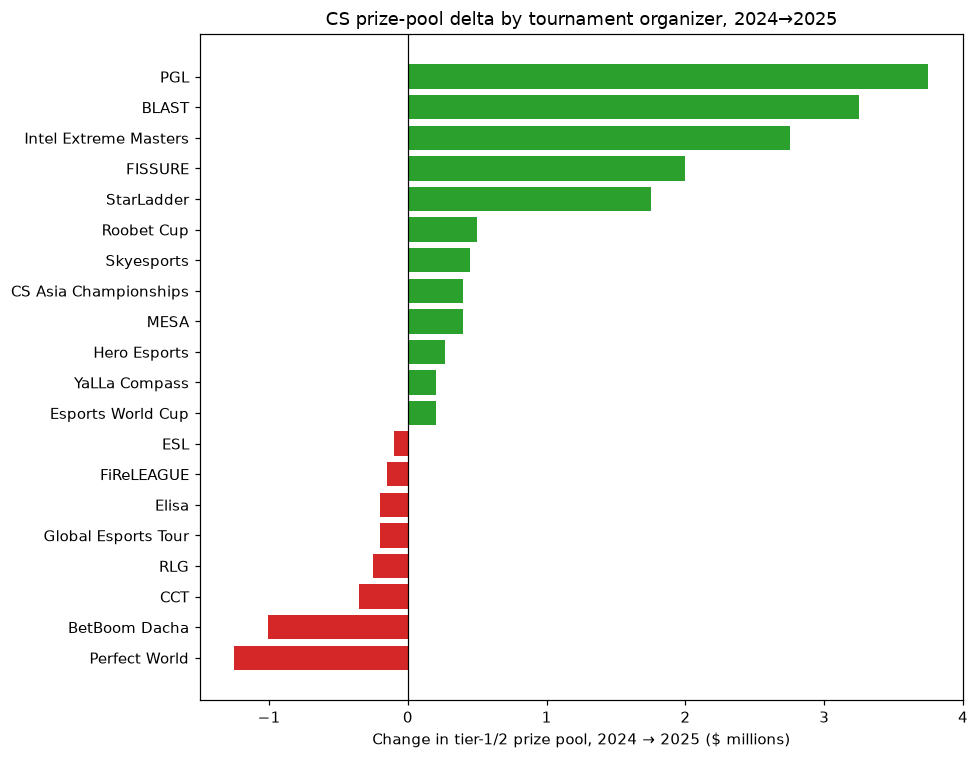

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))
plot_orgs = org_df[org_df["delta"] != 0].sort_values("delta")
colors = ["#2ca02c" if d > 0 else "#d62728" for d in plot_orgs["delta"]]
ax.barh(plot_orgs["org"], plot_orgs["delta"] / 1e6, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Change in tier-1/2 prize pool, 2024 \u2192 2025 ($ millions)")
ax.set_title("CS prize-pool delta by tournament organizer, 2024\u21922025")
plt.tight_layout()
plt.savefig(REPO_ROOT / "notebooks" / "_cs_growth_fig10_organizer_delta.png", dpi=110)
plt.show()

**Read: broad-based across five organizers simultaneously, not one entity
inflating the total.** The five biggest gains sum to \$13.5M against a
\$12.4M net increase (offset by real declines elsewhere — Perfect World
\$-1.25M reflects normal Major-host rotation, not decline; BetBoom Dacha
\$-1.0M, and several smaller regional organizers exiting the tier-1/2
calendar entirely):

- **PGL: +\$3.75M** — from 1 event (the \$1.25M Copenhagen Major) to 4
  events at \$1.25M each. A structural change in how many Major-tier-prize
  events PGL runs, not one bigger check.
- **BLAST: +\$3.25M** — event count rose 7\u219211, and its own flagship World
  Final/Frequent Flyers event doubled ($1M\u2192$2M) alongside new lower-tier
  sub-series (Bounty, Rivals, Open) that didn't exist in 2024's slate.
- **ESL/Intel Extreme Masters: +\$2.75M, same 5 events both years.** This is
  the most striking single pattern: IEM's *non-flagship* regional legs
  (Chengdu, Dallas, and Rio\u2192Melbourne) each roughly **quadrupled**, from
  \$250K to \$1M — a uniform, ecosystem-wide policy change across multiple
  events at once, not one outlier.
- **FISSURE: +\$2.0M, entirely new** — a tournament brand with zero tier-1/2
  presence in 2024, running two \$1M events in 2025.
- **StarLadder: +\$1.75M, effectively new at this tier** — including a
  \$1.25M "StarLadder/2025/Major"-labeled event with no 2024 counterpart.

**Not independently verified beyond what's in this project's own Liquipedia
data** — the pattern (multiple established organizers raising prize pools
in the same direction in the same year, especially IEM's uniform 4x jump
across several events at once) is consistent with a coordinated,
circuit-wide change (e.g. Valve's own regional-circuit requirements for
CS2 tying prize-money minimums to Major-qualification status) rather than
independent organizer decisions, but that's informed speculation from the
shape of the data, not a claim checked against an outside source. Worth
verifying directly against Valve's/each organizer's own public
announcements before this specific explanation goes into anything
externally facing.